# House Price Exploration
这个笔记首先探索一下数据集

## 下载数据 Download the data
我直接从官网手动下载数据，然后解压缩，放到data/raw/里面。里面有4个文件，data_description.txt是各行的介绍，或者说是这些列的介绍，test.csv和train.csv是用到的数据，在train.csv里面建模并做测试，然后最后用test.csv再测试，给出预测结果，提交上去。sample_submission.csv是一个提交样例，最后提交的结果就应该如此。我们的重点就是train.csv


I download the data from Kaggle manually. And then unzip it


我们接下来处理一下路径，由于jupyter notebook的特性，在多次启动的时候可能切换工作目录，导致无法找到数据等，我们需要指定项目根目录，并且指定数据的位置。我们使用Path来获取当前工作目录(cwd)，然后拼接出需要的目录，方面后面使用。

我们必须先获取当前的工作目录，然后基本上就是有两个可能，一个是在根目录，一个是在notebooks/下面，如果是在notebooks/下，只要获取这个目录的上级目录就行了

In [1]:
from pathlib import Path

CURRENT_DIR = Path().cwd()
if CURRENT_DIR.name == "notebooks":
    #当前在notebooks/下面
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    #当前在根目录
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

## 数据预览
首先先把数据拿过来，用pandas读取成dataframe，然后探索一下数据的大概情况，为下一步的清洗和建模做铺垫。

In [2]:
import pandas as pd
df_train = pd.read_csv(RAW_DIR / "train.csv")
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


好的我们已经看到了这个表格，总共有81个列，最后一列是SalePrice，就是价格，是最终要预测的，第一个是Id，其他的都是特征。接下来开始处理，首先我们进一步看一下整体信息

In [3]:
df_train.shape

(1460, 81)

In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

可以看出，完整的数据表格是1460*81，但是不是所有的列都有完整的1460行数据，这个Alley这一列的Non-Null Count才91，实在是太低了，我想后面应该是要直接删除这个列了。数据类型很简单，只有3类，float64(3), int64(35), str(43)，只有3个是float64，大部分数值是int64

In [5]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


进一步查看，可计算数值的列总共有38列，有的列25%，50%分位数的值都是0，有的好像是因为房子没有对应的配套设施，但不清楚是不是数据本身有误

In [6]:
df_train.describe(include="all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


按照提示，我最后还需要看一下numerical / categorical的问题，也就是说，有的变量看起来是数值的，但其实更适合作为类别变量来看待，或者说那些数字并不能表示大小，可能只是id之类的

In [7]:
df_train["MSSubClass"].unique()

array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
       180,  40])

In [8]:
df_train["MSSubClass"].isna().sum()

np.int64(0)

我们可以看到，MSSubClass这一列的取值非常有限，1400多行，没有空位，但是就这么几个值。官网给的解释说，MSSubClass是"The building class"，在data_description.txt里面提到了更细节的含义，20表示1946年及以后的所有样式的一层房子(1-STORY 1946 & NEWER ALL STYLES)，诸如此类的。

这也就是说，这个类看起来全都是数字，却决不能直接当做纯数字放到模型里面去。

我们检查一下所有的数值变量，看看还有没有这种变量。首先需要选择出数值变量，然后再用nunique()统计取值数量，为了方便检查，我们进一步排一下序

In [9]:
df_train.select_dtypes("number").nunique().sort_values()

HalfBath            3
BsmtHalfBath        3
BsmtFullBath        4
FullBath            4
Fireplaces          4
KitchenAbvGr        4
GarageCars          5
YrSold              5
PoolArea            8
BedroomAbvGr        8
OverallCond         9
OverallQual        10
TotRmsAbvGrd       12
MoSold             12
MSSubClass         15
3SsnPorch          20
MiscVal            21
LowQualFinSF       24
YearRemodAdd       61
ScreenPorch        76
GarageYrBlt        97
LotFrontage       110
YearBuilt         112
EnclosedPorch     120
BsmtFinSF2        144
OpenPorchSF       202
WoodDeckSF        274
MasVnrArea        327
2ndFlrSF          417
GarageArea        441
BsmtFinSF1        637
SalePrice         663
TotalBsmtSF       721
1stFlrSF          753
BsmtUnfSF         780
GrLivArea         861
LotArea          1073
Id               1460
dtype: int64

这就有意思了，有很多数值变量都是只有很少的取值的，我们来看看怎么回事。

首先，前面的几个变量是真的可能一个房子配套的数量十分有限，所以取值范围非常小，比如HalfBath表示客用卫生间的数量，这玩意非常稀有，搞不好绝大多数房子都没有；再就是游泳池面积，只有少数房子有游泳池，自然取值也有限。

值得注意的是，OverallCond之类的变量，应该是既可以当做类别变量，也可以当做数值变量的，我觉着这里就让他当数值变量比较好。

经过逐个排查，发现没有其他的变量是有问题的了，需要注意的就只有id和MSSubClass，其他变量取值少基本上就是数量有限或者比较稀有

## 数据质量
接下来看一下数据的质量吧，也就是缺失值、重复值什么的，还有缺失值的含义之类的。

In [10]:
print(df_train.isna().mean().sort_values().to_string())

Id               0.000000
MSSubClass       0.000000
MSZoning         0.000000
LotArea          0.000000
LotShape         0.000000
Street           0.000000
Utilities        0.000000
LandContour      0.000000
Neighborhood     0.000000
Condition1       0.000000
LotConfig        0.000000
LandSlope        0.000000
Condition2       0.000000
BldgType         0.000000
OverallQual      0.000000
HouseStyle       0.000000
Exterior2nd      0.000000
ExterQual        0.000000
OverallCond      0.000000
YearBuilt        0.000000
YearRemodAdd     0.000000
RoofStyle        0.000000
RoofMatl         0.000000
Exterior1st      0.000000
Foundation       0.000000
ExterCond        0.000000
1stFlrSF         0.000000
Heating          0.000000
BsmtFinSF2       0.000000
BsmtUnfSF        0.000000
TotalBsmtSF      0.000000
BsmtFinSF1       0.000000
Fireplaces       0.000000
GarageCars       0.000000
GarageArea       0.000000
Functional       0.000000
KitchenAbvGr     0.000000
KitchenQual      0.000000
CentralAir  

可以看出，大部分列是全满的，但是有的列，基本上全都是空的，比如Fence，缺失率0.8，MiscFeature是0.96，data_description.txt里面写了，Fence的NA表示No Fence，没有藩篱。

MiscFeature表示其他地方没有涉及的杂项，这个大部分数据都没有，也很合理。这个类的NA表示就是None，就是没有，因为该有的信息其他部分已经讲完了。

MasVnrType是指墙外面贴的装饰性石材的类型，如果没有就是None，很多房子都没有，这是所以是0.59

MasVnrArea是墙外石材的面积，这个缺失值非常少，要首先看看MasVnrType是不是None，不是None还缺失的才是真缺失。

Alley是指房子挨着的小巷，绝大部分房子都没有这东西。

PoolQC指游泳池评级，绝大多数房子没有配套的。

FireplaceQu缺的也比较多，这个是NA指的是没有对应设施，0.45的房子没有这个设施。

GarageType表示车库的比例，这个NA也是表示没有车库，不是真正的缺失值。它连带着一些其他的变量也是NA，不过绝大多数房子都有车库，比例非常低。包括其他Garage系列，GarageQual, GarageYrBlt, GarageFinish, GarageType, GarageCond，这些数据的缺失值情况和比例都一样。

Bsmt系列，包括 BsmtFinType1, BsmtQual, BsmtCond和 BsmtFinType2, BsmtExposure，其中前3个是0.025342，后2个是0.026027。经过查阅发现全都是没有地下室。

LotFrontage指的是房子到街道的距离，这个完全没说是什么类型数据，也没解释NA的含义，看来这个NA是真的彻底的数据缺失。

Electrical是指供电类型，这个没有说明NA是什么意思，空缺的值应该是真的缺失值了。




那么综合下来，缺失变量有两种，变量也有两种，缺失有真缺失，和没有对应设备、属性等，不算真正意义的缺失值；

|          | 真正的缺失值       | 没有相应设施或属性 |
|----------|--------------|-----------|
| 类别变量  | 如Electrical  | 如Alley    |
| 数值变量  | 如LotFrontage | ---       |


我们需要记住，这个数据集的真正缺失值不算多，除了LotFrontage以外，其他的缺失值都是零星缺失

## 目标变量分析
接下来，我们重点看一下SalePrice的部分

In [11]:
df_train["SalePrice"].isna().sum()

np.int64(0)

至少这个SalePrice还没有空缺值

In [12]:
df_train["SalePrice"].nunique()

663

有663个可能的值，确实是有不少房子，可能3-5个，也可能更多，对应一个相同的价格，不过平均下来是两个多对应一个相同的值，这也算合理

In [13]:
df_train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

房价平均值是18万，而标准差是8万，按正态分布的话，一个标准差就是10万/26万，两个标准差就是2万/34万，这里最大的最低是3万，最高的是75万，看来不是很符合正态分布，可能右侧长尾，我们干脆画个图看看。可以直接使用pandas的.hist()函数，然后使用matplotlib的plt.show()展示就可以了。

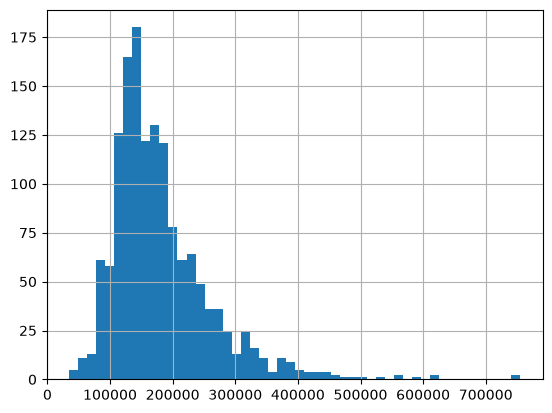

In [14]:
import matplotlib.pyplot as plt
df_train["SalePrice"].hist(bins=50)
plt.show()

不过总的来说，这个值还是合理的，右侧长尾的，近似正态分布。回归的残差如果不符合正态分布，那么线性模型的有效性就要打问号，不过目前我们还没到那一步，我只是想到这一点了。

房价明显右偏，也就是说，房价分布不均匀，大部分是中低价格的，少数高价值房子价格可以顶到非常高，我们也许需要预测对数价格，这样可能效果好一点

## 特征分析（数值变量与类别变量）
接下来我们来分析一下数值变量的特征，首先来看看他们的一些描述。

由于pandas自动省略内容，我们这里临时解除最大列数的限制，然后看一下各个数值的统计量。记得用完一定要关闭这个限制

In [15]:
pd.set_option('display.max_columns', None)
df_train.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [16]:
pd.reset_option('display.max_columns')

我们看到，后面有些变量有很多0，可能来自于类别变量的NA，或者单纯就是0。

有的变量的大小没有意义，比如MSSubClass，这个前面已经提过了，其实应该是类别变量更合适。所以它的什么平均数中位数也没有意义。

不同的变量大小相差很大，可能需要scaling之类的步骤，来让模型表现更好。

我们接下来看看，整体的趋势如何，我猜想各个变量和目标变量SalePrice应该大致符合线性关系，我们来看一些典型的变量的情况。

我想了一下，常见的应该有
* 面积LotArea
* 房间数量（卧室数量等）Bedroom，或者说BedroomAbvGrd
* 房子的评级之类，比如OverallCond
* 建造年份，YearBuilt

我还发现一个问题，就是这个描述字段和表格里的字段不一样，这个也是数据不一致的问题。在描述字段里面，卧室的数量就是Bedroom，但是在表格里面，实际叫做BedroomAbvGrd，这也是数据质量方面的问题

我们使用matplotlib来画图这4张图，用plt.subplots(2,2)返回图片对象和坐标系，在坐标系里面指定绘制内容即可

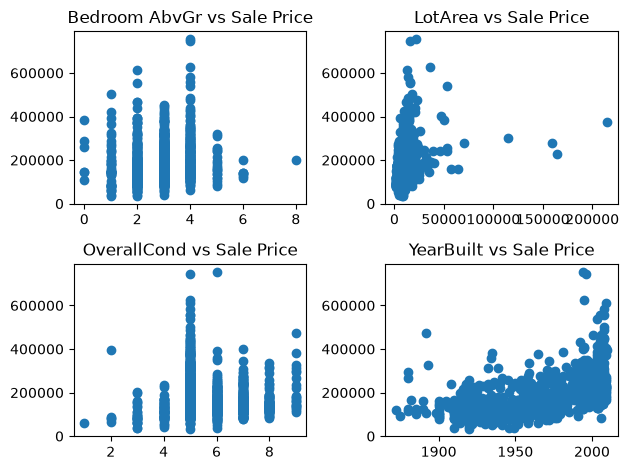

In [17]:
fig, axes = plt.subplots(2,2)

axes[0,0].scatter(df_train["BedroomAbvGr"], df_train["SalePrice"])
axes[0,0].set_title("Bedroom AbvGr vs Sale Price")

axes[0,1].scatter(df_train["LotArea"], df_train["SalePrice"])
axes[0,1].set_title("LotArea vs Sale Price")

axes[1,0].scatter(df_train["OverallCond"], df_train["SalePrice"])
axes[1,0].set_title("OverallCond vs Sale Price")

axes[1,1].scatter(df_train["YearBuilt"], df_train["SalePrice"])
axes[1,1].set_title("YearBuilt vs Sale Price")

plt.tight_layout()
plt.show()

啊，这里我发现了一个问题，那就是对于类别变量，似乎应该画boxplot，而不是这种散点图。

pandas可以直接画，直接从dataframe对象里面引出来方法，指定参数就可以画了

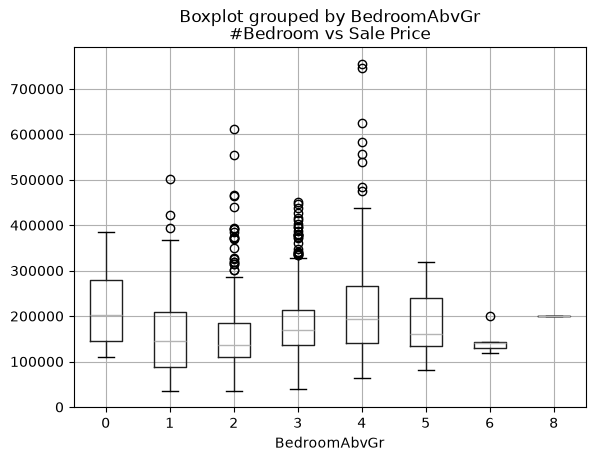

In [18]:
df_train.boxplot(column="SalePrice", by="BedroomAbvGr")
plt.title("#Bedroom vs Sale Price")
plt.show()

我们尝试把他们画在一起试试，pandas和matplotlib结合使用非常简单，只需要在pandas的函数里面指定matplotlib的子图位置就行了。

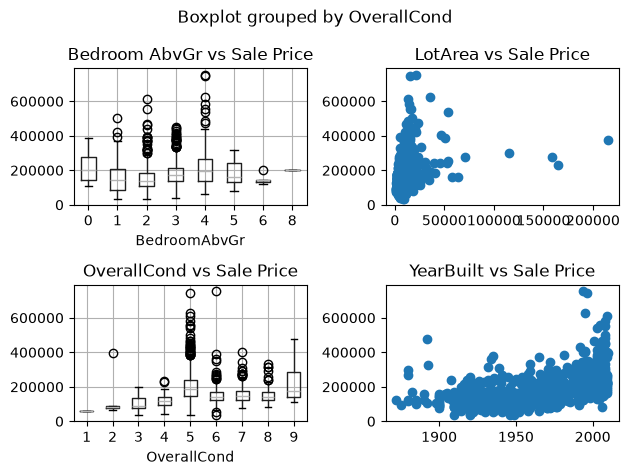

In [19]:
fig, axes = plt.subplots(2,2)


df_train.boxplot(column="SalePrice", by="BedroomAbvGr", ax=axes[0,0])
axes[0,0].set_title("Bedroom AbvGr vs Sale Price")

axes[0,1].scatter(df_train["LotArea"], df_train["SalePrice"])
axes[0,1].set_title("LotArea vs Sale Price")

df_train.boxplot(column="SalePrice", by="OverallCond", ax=axes[1,0])
axes[1,0].set_title("OverallCond vs Sale Price")

axes[1,1].scatter(df_train["YearBuilt"], df_train["SalePrice"])
axes[1,1].set_title("YearBuilt vs Sale Price")

plt.tight_layout()
plt.show()

这样就舒服了，并且我们进一步可以看出来，大致上，它们都是呈正相关的，但是有趣的是，卧室的数量和房价并没有明显的正相关关系，我个人猜测是，可能2卧室的房子比1卧室的房子多，因为供求关系，所以才价格更低了，而卧室太多的房子，而4卧室以上的房子可能不太常规，超出了一般人的需求，所以价格也不如预想的那样上升

还有一个问题，就是似乎这个数据集里面的outliers相当多，箱线图里面密密麻麻的全都是，我们可以统计一下。由于我们不确定这些变量的分布，所以我们不能使用标准差来判断outliers，而是要借助分位数，Q1-1.5IQR以下，和Q3+1.5IQR以上，就是异常值

In [20]:
Q1 = df_train["BedroomAbvGr"].quantile(0.25)
Q3 = df_train["BedroomAbvGr"].quantile(0.75)
IQR = Q3 - Q1
lower_bounds = Q1 - 1.5*IQR
upper_bounds = Q3 + 1.5*IQR

outliers = df_train[(df_train["BedroomAbvGr"] < lower_bounds) | (df_train["BedroomAbvGr"] > upper_bounds)]
print(outliers)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
53      54          20       RL         68.0    50271   Pave   NaN      IR1   
118    119          60       RL         90.0    12376   Pave   NaN      Reg   
137    138          90       RL         82.0    11070   Pave   NaN      Reg   
144    145          90       RM         70.0     9100   Pave   NaN      Reg   
189    190         120       RL         41.0     4923   Pave   NaN      Reg   
198    199          75       RM         92.0     5520   Pave   NaN      Reg   
291    292         190       RL         55.0     5687   Pave  Grvl      Reg   
324    325          80       RL         96.0    11275   Pave   NaN      Reg   
328    329          75       RL          NaN    11888   Pave  Pave      IR1   
330    331          90       RL          NaN    10624   Pave   NaN      IR1   
386    387          50       RL         58.0     8410   Pave   NaN      Reg   
570    571          90       RL         74.0    1310

只有35个，看来被图片蒙蔽了，并没有那么多

In [21]:
for i in range(0,6):
    print(f"卧室数量 = {i} 的房子有",df_train[df_train["BedroomAbvGr"] == i].shape[0])


卧室数量 = 0 的房子有 6
卧室数量 = 1 的房子有 50
卧室数量 = 2 的房子有 358
卧室数量 = 3 的房子有 804
卧室数量 = 4 的房子有 213
卧室数量 = 5 的房子有 21


## 特征关系
这里我主要想看一下各个变量之间的相关性，其实这一部分应该先看，好对全局有个整体把控

我们需要先筛选出数值变量，然后使用.corrwith()计算相关系数，再用.abs()取绝对值，再排序

In [22]:
num_df_train = df_train.select_dtypes("number")
correlations = num_df_train.corrwith(df_train["SalePrice"]).abs().sort_values()
print(correlations)

BsmtFinSF2       0.011378
BsmtHalfBath     0.016844
MiscVal          0.021190
Id               0.021917
LowQualFinSF     0.025606
YrSold           0.028923
3SsnPorch        0.044584
MoSold           0.046432
OverallCond      0.077856
MSSubClass       0.084284
PoolArea         0.092404
ScreenPorch      0.111447
EnclosedPorch    0.128578
KitchenAbvGr     0.135907
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
dtype: float

没想到美国房价竟然和什么车库面积关系这么强，这就是不符合我的生活经验了，这也是事情有趣的地方，不通过详尽的数据分析，评直觉是没办法抓住真实规律的。

以后也要长记性了，以后拿到数据集可以先算相关系数，这样更方便，前面探索了半天，没头苍蝇乱撞，还是这样更有效率。比如GrLivArea这种，我看解释是地上总面积，竟然把这个给忘了，自己想真的不靠谱。

不过我感觉CarageArea和GarageCars应该是存在共线性的，后面做线性回归要注意

correlation只能看数值变量的关系，而且只能看一维变量，我们可以计算互信息，这个定义更广泛，可以计算数值变量和类别变量，还可以寻找到非线性的关联，不过由于计算量大、没有参考基准、没有方向性，所以也不能完全替代相关系数，可以当做补充手段。

还有个问题，就是互信息不能允许缺失值，所以我们还需要专门处理一下数据

In [23]:
from sklearn.feature_selection import mutual_info_regression

#复制数据，方便处理
X = df_train.select_dtypes(exclude="number").copy()
Y = df_train["SalePrice"]
# 逐列遍历，填补空缺，
for col in X.columns:
    X[col] = X[col].fillna("Missing")

# 给列编码，选取其中的类别变量
discrete_features = []

for col in X.columns:
    # 全都转换成category类型并编码
    X[col] = X[col].astype("category").cat.codes
    # 全部标记为离散变量
    discrete_features.append(True)

# 计算互信息
mi_scores = mutual_info_regression(X,Y, discrete_features=discrete_features, random_state=42)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print(mi_series)

Neighborhood     5.333864e-01
BsmtQual         3.289178e-01
KitchenQual      3.280555e-01
ExterQual        3.258152e-01
GarageFinish     2.624376e-01
FireplaceQu      2.126179e-01
GarageType       2.006262e-01
Foundation       1.997301e-01
HeatingQC        1.629027e-01
Exterior2nd      1.582155e-01
BsmtFinType1     1.514225e-01
Exterior1st      1.321657e-01
MSZoning         1.193209e-01
MasVnrType       9.612181e-02
LotShape         8.714697e-02
SaleType         7.951645e-02
BsmtExposure     7.776924e-02
GarageCond       7.680336e-02
HouseStyle       7.649751e-02
SaleCondition    7.495093e-02
GarageQual       6.906955e-02
CentralAir       6.575109e-02
BsmtCond         5.394095e-02
Electrical       4.966959e-02
PavedDrive       4.529164e-02
BldgType         4.307114e-02
Fence            4.197335e-02
BsmtFinType2     3.289752e-02
Alley            2.817207e-02
LandContour      2.710099e-02
Condition1       2.447840e-02
Heating          1.449027e-02
ExterCond        1.242474e-02
LotConfig 

果然还是有重要信息的，Neighborhood和SalePrice的互信息有0.5，虽然不能直接确定这个值到底是什么概念，但是看Utilities等就知道，后面的内容接近0，那是真的不会有人在意，实际上Neighborhood表示地段，这当然会极大的影响房价，非常合理。

BsmtQual, KitchenQual, ExterQual等也都会影响生活质量，因此对房价也有一定的影响。

我们可以进一步计算数值变量的互信息，来获得更清晰的对比

## 异常值与错误值
还有，我们接下来专门探查一下异常值和错误值的问题。其实严格讲这应该属于数据质量的部分，不过我之前忘了，现在补上。我想到的第一个办法就是观察IQR，我们取出所有的数值变量，计算IQR，再分析异常值。

使用`.columns`取出所有列，再用`.quantile()`计算分位数，构成IQR，再构造上下界，然后筛选出所有的界外数值。我们使用或逻辑构造出一个布尔值矩阵

In [24]:
# pd.set_option("display.max_columns", None)
# # 取出所有数值列
# num_columns = df_train.select_dtypes("number").columns
# Q1 = df_train.select_dtypes("number").quantile(0.25)
# Q3 = df_train.select_dtypes("number").quantile(0.75)
# IQR = Q3 - Q1
# # 构造异常值布尔矩阵
# outliers_mask = (df_train[num_columns] < Q1 - 1.5*IQR) | (df_train[num_columns] > Q3 + 1.5*IQR)
#
# outliers_mask.describe()

In [25]:

# valid_outliers = outliers_mask & df_train[num_columns].notna()
# valid_outliers.sum()

那么，具有超过下界异常值的变量有：

* LotFrontage       42
* LotArea           2
* OverallCond      31
* YearBuilt         7
* TotalBsmtSF      37
* BedroomAbvGr      6
* KitchenAbvGr      1

我们挨个排查。

In [26]:
# pd.reset_option('display.max_rows')
# print("df_train中，根据LotFrontage一列是Outlier且不是空值这一条件筛选出的子dataframe的行数为：",end="")
# print(df_train.loc[df_train["LotFrontage"].notna() & ~outliers_mask["LotFrontage"]].shape[0])
#
# print("df_train中，根据LotArea一列是Outlier且不是空值这一条件筛选出的子dataframe的行数为：",end="")
# print(df_train.loc[df_train["LotArea"].notna() & ~outliers_mask["LotArea"]].shape[0])
#
# print("df_train中，根据OverallCond一列是Outlier且不是空值这一条件筛选出的子dataframe的行数为：",end="")
# print(df_train.loc[df_train["OverallCond"].notna() & ~outliers_mask["OverallCond"]].shape[0])
#
# print("df_train中，根据YearBuilt一列是Outlier且不是空值这一条件筛选出的子dataframe的行数为：",end="")
# print(df_train.loc[df_train["YearBuilt"].notna() & ~outliers_mask["YearBuilt"]].shape[0])
#
# print("df_train中，根据TotalBsmtSF一列是Outlier且不是空值这一条件筛选出的子dataframe的行数为：",end="")
# print(df_train.loc[df_train["TotalBsmtSF"].notna() & ~outliers_mask["TotalBsmtSF"]].shape[0])
#
# print("df_train中，根据BedroomAbvGr一列是Outlier且不是空值这一条件筛选出的子dataframe的行数为：",end="")
# print(df_train.loc[df_train["BedroomAbvGr"].notna() & ~outliers_mask["BedroomAbvGr"]].shape[0])
#
# print("df_train中，根据KitchenAbvGr一列是Outlier且不是空值这一条件筛选出的子dataframe的行数为：",end="")
# print(df_train.loc[df_train["KitchenAbvGr"].notna() & ~outliers_mask["KitchenAbvGr"]].shape[0])

## 总结
我们总结一下目前的探索，我认为至少已经把存在的问题看到了，虽然可能还不够详尽。总的来说，要点如下：

1. 数据81列1460行，也就是80个变量，1460个数据点，所以必定要做特征工程，大大减少特征数量才行
2. 数值变量有38行，大部分是整数，不过其中也有包括id之类的变量，显然需要后续排除
3. 有的数值变量虽然是数值变量，但实际上是类别变量，不过经过排查就id和MSSubClass需要区别对待
4. 不同变量的NA含义不同，有的表示没有该设备或属性，我们可以通过一些手段来处理，真缺失很少
5. 数据集的缺失值不多，除了LotFrontage这个变量有17.7%的真缺失以外，其他都是接近或低于5%的，可以手动处理
6. 目标变量SalePrice的分布是右偏的，可能需要使用对数处理
7. 不同的变量大小相差很大，可能需要scaling
8. 通过计算correlation找到了几个重点变量，不过只计算了数值变量的，其中GarageArea和GarageCars明显存在共线性
9. 通过计算Mutual Information确定Neighborhood等变量的重要性，这些一定也是要考虑进去的
10. 部分表格有的列名写错了，目前发现的有Kitchen和Bedroom两列





